**Proyecto Final Programación**

**Daniela Guzmán**

**1. Definición del objetivo del análisis**

**Nuestra pregunta guía**
¿Cuáles son las características físicas y de forma de las células que más influyen para saber si un tumor de mama es benigno o maligno?

**¿Por qué es importante este estudio?**
Este análisis vale mucho la pena porque el cáncer de mama afecta a muchas personas en el mundo. Si logramos entender qué detalles de las células cambian cuando el tumor es peligroso, los médicos podrían dar diagnósticos mucho más rápidos y acertados, lo que ayuda a empezar los tratamientos a tiempo y salvar vidas.

**¿Se puede lograr con estos datos?**
Sí, es totalmente alcanzable porque la base de datos tiene las medidas exactas del tamaño, grosor y forma de los núcleos de las células de cada paciente.

**2. Descripción de la base de datos**

**Origen de los datos**
La base de datos se llama Breast Cancer Wisconsin y los datos se consiguieron analizando imágenes digitales de muestras tomadas con agujas finas en masas mamarias. Está disponible de forma libre en internet en la página de Kaggle.

**¿Qué contiene la base de datos?**
Al principio el archivo viene con 569 filas (que representan a los pacientes) y 32 columnas.

La columna más importante es la del diagnóstico, que nos dice si el tumor es maligno o benigno. Las demás columnas son números que miden cosas de las células, como el radio, la textura, el perímetro, el área y qué tan deformes o simétricas son.

**Librerias y base de datos**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**3. Preprocesamiento y limpieza de datos**

Para que las gráficas y el análisis salgan bien y no tengan errores, vamos a limpiar la base de datos con los siguientes pasos:

1. Quitamos la columna 'id' porque es solo el número de cédula o registro del paciente y no aporta nada para saber si un tumor es malo o bueno.
2. Borramos cualquier columna que venga totalmente vacía por errores al descargar el archivo.
3. Buscamos y eliminamos filas repetidas para no alterar los resultados.

In [2]:
df.drop(columns=['id'], inplace=True, errors='ignore')
df.dropna(axis=1, how='all', inplace=True)
df.drop_duplicates(inplace=True)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

None

**4. Análisis exploratorio y visualizaciones**

**Gráfica 1: Cantidad de casos benignos y malignos**

/tmp/ipykernel_2975/3692177427.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette=['steelblue', 'lightcoral'])


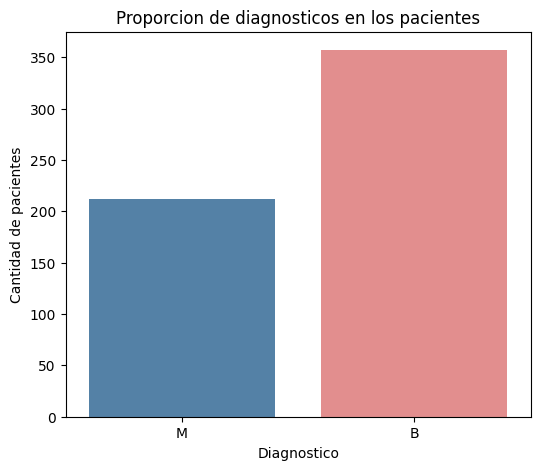

In [3]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='diagnosis', palette=['steelblue', 'lightcoral'])
plt.title('Proporcion de diagnosticos en los pacientes')
plt.xlabel('Diagnostico')
plt.ylabel('Cantidad de pacientes')
plt.show()

**Lo que nos muestra esta gráfica:**
Aquí podemos ver el total de pacientes que hay en los datos según su diagnóstico. Notamos que hay más casos de tumores benignos (buenos) que malignos (malos). Conocer esto nos sirve para saber cómo están repartidos los datos antes de revisar las medidas.

**Gráfica 2: Distribución del radio de las células**

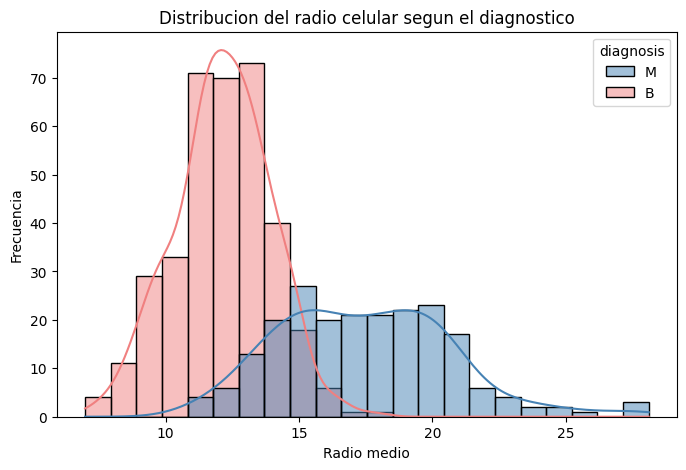

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, palette=['steelblue', 'lightcoral'])
plt.title('Distribucion del radio celular segun el diagnostico')
plt.xlabel('Radio medio')
plt.ylabel('Frecuencia')
plt.show()

**Lo que nos muestra esta gráfica:**
Este histograma nos deja ver que las células de los tumores benignos suelen ser más pequeñas y sus tamaños están muy agrupados en valores bajos. En cambio, las células de los tumores malignos tienen radios mucho más grandes y variados, lo que indica que crecen sin control.

**Gráfica 3: Comparación del área de las células**

/tmp/ipykernel_2975/3704726121.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y='area_mean', palette=['steelblue', 'lightcoral'])


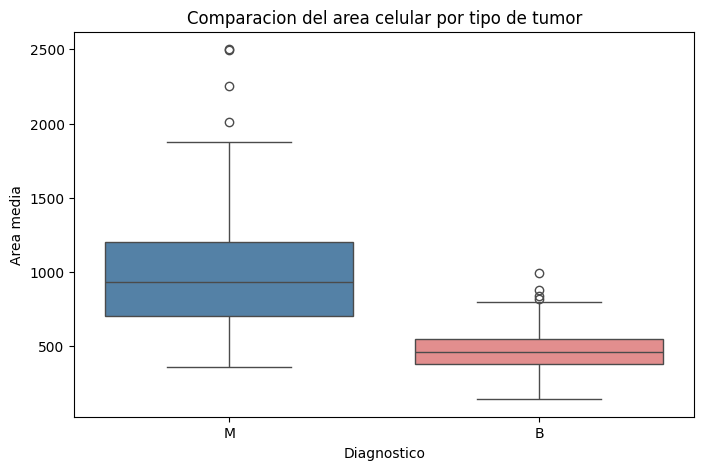

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='diagnosis', y='area_mean', palette=['steelblue', 'lightcoral'])
plt.title('Comparacion del area celular por tipo de tumor')
plt.xlabel('Diagnostico')
plt.ylabel('Area media')
plt.show()

**Lo que nos muestra esta gráfica:**
Esta gráfica de caja nos confirma que el área de las células cambia muchísimo según el diagnóstico. La caja de los tumores malignos está mucho más arriba, lo que significa que su área promedio es el doble o triple que la de los benignos. También se ven unos puntos sueltos arriba que son casos atípicos de células extremadamente grandes.

**Gráfica 4: Relación entre la textura y el perímetro celular**

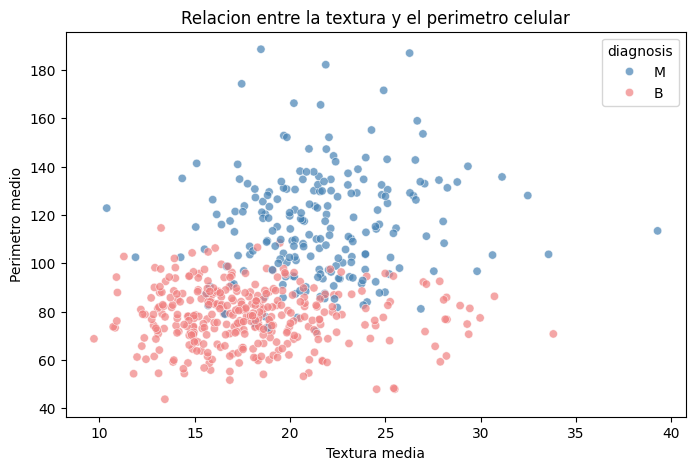

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='texture_mean', y='perimeter_mean', hue='diagnosis', palette=['steelblue', 'lightcoral'], alpha=0.7)
plt.title('Relacion entre la textura y el perimetro celular')
plt.xlabel('Textura media')
plt.ylabel('Perimetro medio')
plt.show()

**Lo que nos muestra esta gráfica:**
Al cruzar estas dos medidas en un gráfico de dispersión, vemos cómo se forman dos grupos muy claros. Los puntos de color salmón (malignos) se van hacia arriba a medida que el perímetro de la célula aumenta. La textura también influye, pero el perímetro es el que realmente marca la diferencia para separar los casos malos de los buenos.

**Gráfica 5: Mapa de calor de las características de la célula**

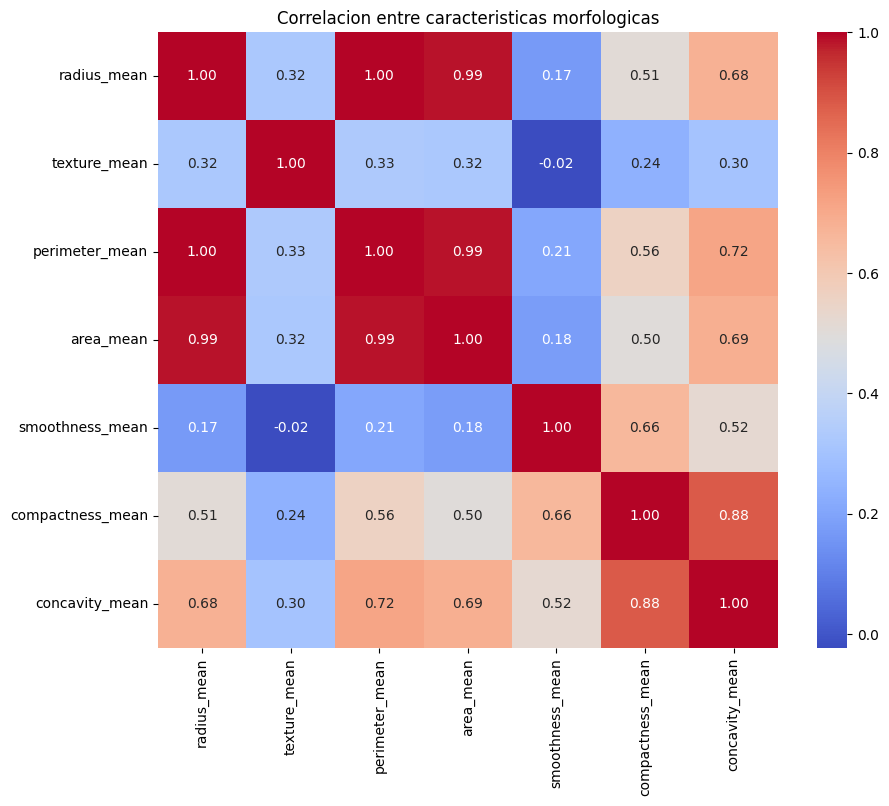

In [7]:
columnas_medias = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean']
correlacion = df[columnas_medias].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlacion entre caracteristicas morfologicas')
plt.show()

**Lo que nos muestra esta gráfica:**
Este mapa nos ayuda a ver qué variables se mueven juntas. Por ejemplo, el radio, el perímetro y el área tienen una relación casi perfecta de 1.00, lo que tiene sentido porque si una célula es más grande, sus otras medidas también aumentan. También vemos que la concavidad y la compacidad se relacionan bastante, lo que significa que las células deformes también suelen ser más complejas en su estructura.

**5. Conclusiones finales**

**Principales hallazgos en los datos**
* **El tamaño es clave:** Las medidas que tienen que ver con el tamaño de la célula (como el área, el perímetro y el radio) son las más importantes para descubrir si un tumor es peligroso. Si estas medidas salen muy altas, el tumor casi siempre es maligno.
* **Formas extrañas:** Las células de los tumores malignos no solo son grandes, sino que también son más deformes, hundidas (concavidad) y arrugadas, mientras que las células buenas son más redondas y parejas.
* **Datos repetidos por geometría:** Vi que el radio, el perímetro y el área nos dicen casi lo mismo. En un trabajo futuro bastaría con usar una sola de estas tres para no enredar el análisis.

**Respuesta al objetivo inicial**

Logre responder la pregunta del principio por completo. Las características que más influyen para clasificar un tumor son el área y el perímetro de las células. Gracias a las gráficas pudimos ver que hay una línea muy clara que divide el tamaño de las células buenas de las células malas.

**Limitaciones de este trabajo**

Hay que tener en cuenta que estos datos son de unas pocas pacientes de un hospital de Estados Unidos y se tomaron en los años 90, por lo que son datos antiguos. Además, el análisis se hace solo mirando la forma de la célula en fotos, pero no sabemos la edad de la paciente, si tiene familiares con cáncer ni otros datos médicos que ayudarían mucho a dar un diagnóstico 100% seguro.

**Siguientes pasos recomendados**

Si este proyecto continuara, el siguiente paso sería usar estas variables para crear un modelo de ia en Python que aprenda a clasificar los tumores de forma automática.